<a href="https://colab.research.google.com/github/gdconstantino2/Arduino/blob/main/T1_Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 — Clasificación de piezas LEGO
**IIC2613 Inteligencia Artificial — 2026**

Este notebook contiene únicamente la **carga de datos** y algunas celdas de **referencia**. Todo el
desarrollo (extracción de features, modelos y análisis) lo implementas **tú**, siguiendo el enunciado.

- Entrega el notebook con **todas las celdas ejecutadas**.
- Mantén `piezas_dataset.csv` **junto al notebook** (en el repo).
- Modelos permitidos: **clásicos** (SVM, Random Forest, Árbol de Decisión, KNN, etc.) — *sin deep learning*.

In [18]:
import os, re, glob, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from PIL import Image
try:
    from IPython.display import display
except Exception:
    display = print

SEED = 42
np.random.seed(SEED)
IMG_SIZE = 128

def load_gray(path, size=IMG_SIZE):
    return np.asarray(Image.open(path).convert('L').resize((size, size)), dtype=np.uint8)

## Track A — Clasificación a partir de imágenes

Las siguientes celdas **descargan y preparan las imágenes**: carga y organización, análisis exploratorio
y una **segmentación de referencia**. **Ejecútalas** y luego desarrolla tu solución según el enunciado.

In [19]:
# === Carga y organización de imágenes (ejecutar) ===
CSV_PATH = 'piezas_dataset.csv'      # manifiesto de piezas (su ficha técnica se usa en la Parte 2)
WORK_DIR = 'data'

def find_images(root):
    return sorted(glob.glob(os.path.join(root, '**', '*.png'), recursive=True))

def get_data_root():
    # 1) copia local junto al notebook (carpeta plana 'dataset/')
    for cand in ['dataset', os.path.join('LEGO brick images', 'dataset')]:
        if os.path.isdir(cand) and glob.glob(os.path.join(cand, '*.png')):
            return cand
    # 2) Kaggle vía kagglehub (Colab). Si pide login, ejecuta antes: kagglehub.login()
    try:
        import kagglehub
    except ImportError:
        os.system('pip -q install kagglehub'); import kagglehub
    path = kagglehub.dataset_download('joosthazelzet/lego-brick-images')
    flat = os.path.join(path, 'dataset')
    return flat if os.path.isdir(flat) else path

assert os.path.exists(CSV_PATH), (
    'No se encuentra ' + CSV_PATH + '. Debe estar en la misma carpeta que este notebook '
    '(en Colab: súbelo o monta el repositorio).')
manifest = pd.read_csv(CSV_PATH, usecols=['filename', 'label'])
RAW_DIR = get_data_root()
avail = {os.path.basename(p): p for p in find_images(RAW_DIR)}
print('Fuente de imágenes:', RAW_DIR, '|', len(avail), 'archivos .png encontrados')

if os.path.isdir(WORK_DIR):
    shutil.rmtree(WORK_DIR)
paths, faltantes = [], 0
for _, r in manifest.iterrows():
    dest = avail.get(r['filename'])
    if dest is None:
        paths.append(None); faltantes += 1; continue
    dest_dir = os.path.join(WORK_DIR, str(r['label']))
    os.makedirs(dest_dir, exist_ok=True)
    destino = os.path.join(dest_dir, r['filename'])
    shutil.copy(dest, destino)
    paths.append(destino)

df = manifest.copy()
df['path'] = paths
if faltantes:
    print('ADVERTENCIA:', faltantes, 'de', len(manifest),
          'imágenes del CSV no aparecieron en', RAW_DIR)
df = df[df['path'].notna()].reset_index(drop=True)

# Si algo salió mal, es mejor fallar acá que arrastrar un dataset incompleto.
assert len(df) > 0, (
    'No se copió ninguna imagen. Revisa que la descarga haya terminado y que RAW_DIR apunte a '
    'la carpeta con los .png. Si el problema persiste, avísanos por una issue.')
assert df['label'].nunique() == manifest['label'].nunique(), (
    'Faltan clases completas: se esperaban ' + str(manifest['label'].nunique()) +
    ' piezas y quedaron ' + str(df['label'].nunique()) + '.')

clases = sorted(df['label'].unique())
print('Piezas a clasificar:', len(clases))
print('Imágenes organizadas en', WORK_DIR + '/:', len(df))
display(df['label'].value_counts())


Using Colab cache for faster access to the 'lego-brick-images' dataset.
Fuente de imágenes: /kaggle/input/lego-brick-images/dataset | 40000 archivos .png encontrados
Piezas a clasificar: 8
Imágenes organizadas en data/: 2400


,count
label,
3040 roof tile 1x2,300
3004 brick 1x2,300
3062 Round Brick 1x1,300
3001 brick 2x4,300
3022 Plate 2x2,300
3005 brick 1x1,300
3069 Flat Tile 1x2,300
3003 brick 2x2,300


### Análisis exploratorio

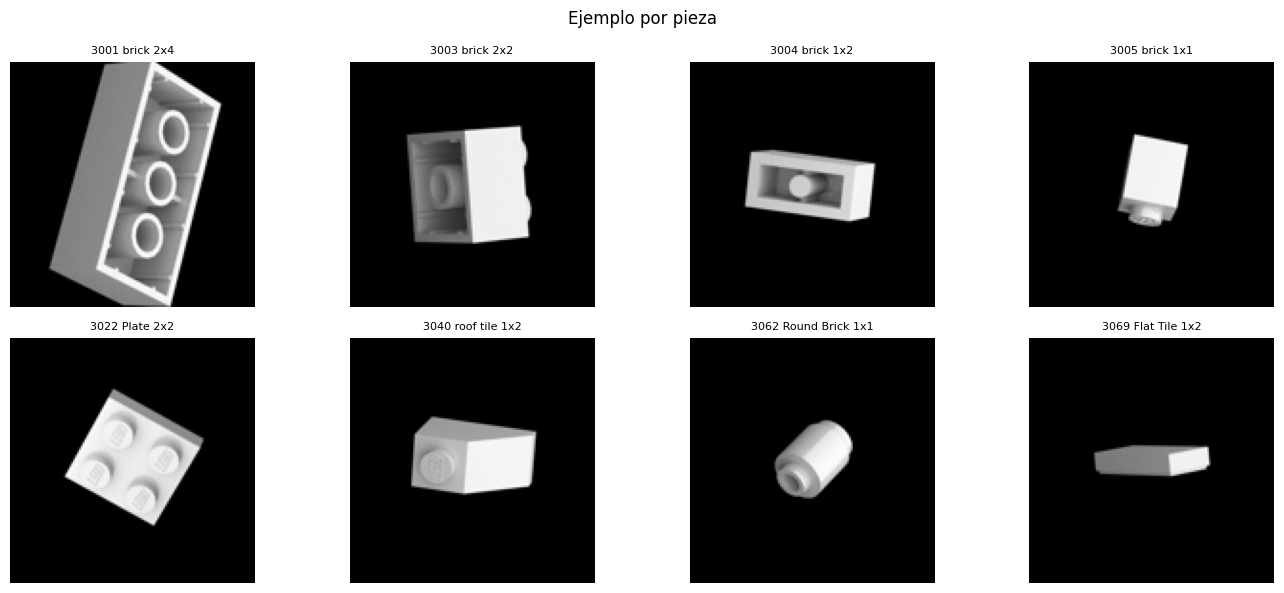

In [20]:
# === EDA: una imagen de ejemplo por pieza ===
n = len(clases)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(14, 6))
for ax, c in zip(axes.ravel(), clases):
    ax.imshow(load_gray(df[df.label == c].iloc[0].path), cmap='gray')
    ax.set_title(c, fontsize=8); ax.axis('off')
for ax in axes.ravel()[n:]:
    ax.axis('off')
plt.suptitle('Ejemplo por pieza'); plt.tight_layout(); plt.show()

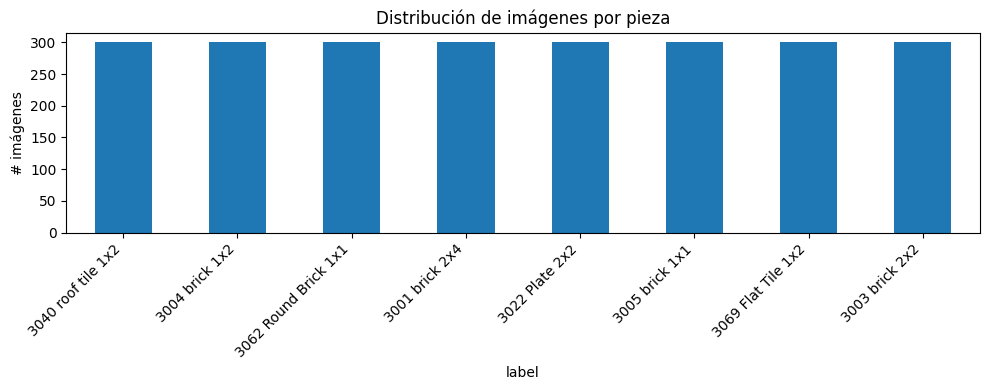

In [21]:
# === EDA: distribución de imágenes por pieza ===
plt.figure(figsize=(10, 4))
df.label.value_counts().plot(kind='bar')
plt.title('Distribución de imágenes por pieza'); plt.ylabel('# imágenes')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### Preprocesamiento y segmentación (referencia)

Las imágenes son monocromas: la **forma** es lo que distingue a las piezas. La función `segment`
separa la pieza del fondo y devuelve una **máscara** binaria; puedes usarla como base para construir
tus características. Es solo una referencia: puedes modificarla o reemplazarla.

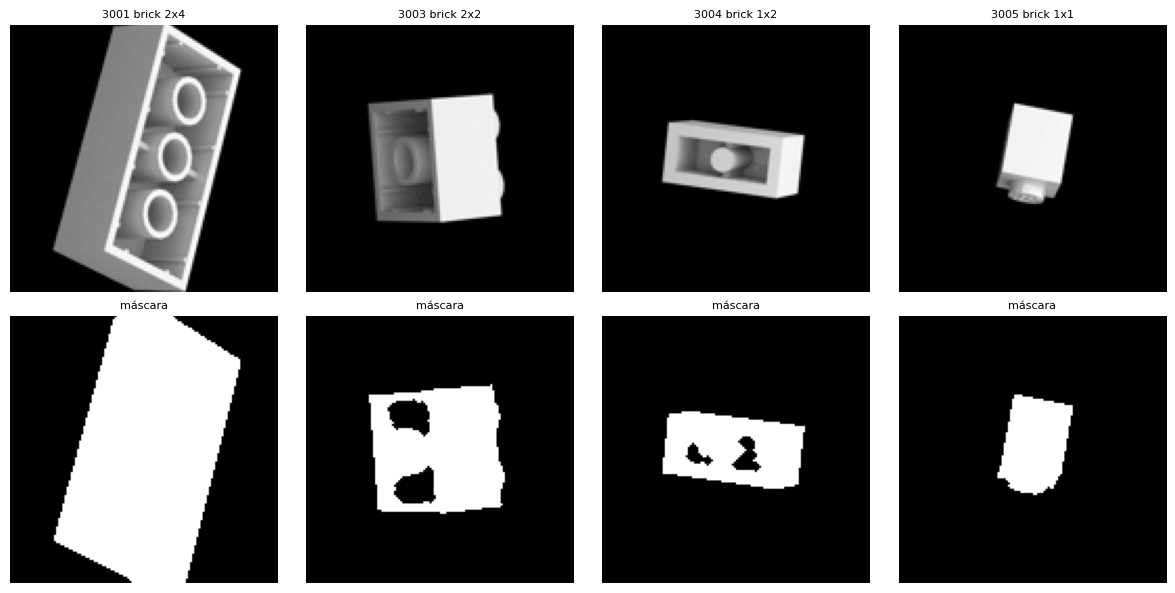

In [22]:
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk

def segment(img):
    border = np.concatenate([img[0, :], img[-1, :], img[:, 0], img[:, -1]])
    bg = np.median(border)
    diff = np.abs(img.astype(int) - bg).astype(np.uint8)
    try:
        t = threshold_otsu(diff)
    except Exception:
        t = 10
    mask = diff > max(int(t), 10)
    mask = binary_closing(mask, disk(2))
    mask = remove_small_objects(mask, 50)
    return mask

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, c in enumerate(clases[:4]):
    img = load_gray(df[df.label == c].iloc[0].path)
    m = segment(img)
    axes[0, i].imshow(img, cmap='gray'); axes[0, i].set_title(c, fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(m, cmap='gray'); axes[1, i].set_title('máscara', fontsize=8); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

### Tu desarrollo — Track A

Desde aquí en adelante, **implementa tu solución** (agrega las celdas que necesites) según el enunciado:
extracción de características (con fuentes), escalado/normalización, división train/test y el
entrenamiento y comparación de los 4 modelos con sus combinaciones de hiperparámetros.

> **Importante:** la partición *train*/*test* que definas acá es la que debes **reutilizar en los
> Track B y C** (mismos índices, misma semilla). Los tres tracks se comparan entre sí, y esa
> comparación solo es válida si los modelos se evalúan sobre el mismo conjunto de prueba.


In [23]:
from skimage.measure import label, regionprops
def extraer_features(df, i):
    filename = df.iloc[i]['filename']
    label_val = df.iloc[i]['label']
    imagem = load_gray(df.iloc[i]['path'], 128)
    ver = segment(imagem)
    imagem_rotulada = label(ver)
    region = regionprops(imagem_rotulada)
    circularidade = 0
    if region:
      maior_region = max(region, key=lambda x: x.area)
      min_row, min_col, max_row, max_col = maior_region.bbox
      altura = max_row - min_row
      largura = max_col - min_col
      eccentricity = maior_region.eccentricity
      perimetro = maior_region.perimeter
      if perimetro > 0:
        circularidade = (4 * np.pi * maior_region.area) / (perimetro ** 2)
      else:
        circularidade = 0
      res =  {'filename': filename,
        'label': label_val,
        'area': maior_region.area,
        'solidity': maior_region.solidity,
        'eccentricity': eccentricity,
        'circularidade' : circularidade,
        'altura': altura,
        'largura': largura,
        'aspect_ratio': largura / altura }
      for idx, hu_val in enumerate(maior_region.moments_hu):
        res[f'hu_{idx}'] = hu_val

      return res

    else:
      res = {
        'filename': filename,
        'label': label_val,
        'area': 0,
        'solidity': 0,
        'eccentricity': 0,
        'circularidade' : circularidade,
        'altura': 0,
        'largura': 0,
        'aspect_ratio': 0,
    }
      for idx in range(7):
        res[f'hu_{idx}'] = 0
      return res


In [24]:
#EXTRAINDO OS VALORES PARA DEPOIS USAR COM ALGUM MOMENTO DE HU, HOG OU LBP
lista_de_recursos = []

for i in range(len(df)):
    dic_features = extraer_features(df, i)
    lista_de_recursos.append(dic_features)

df_final = pd.DataFrame(lista_de_recursos)
df_final.to_csv('features_separadas.csv', index = False)

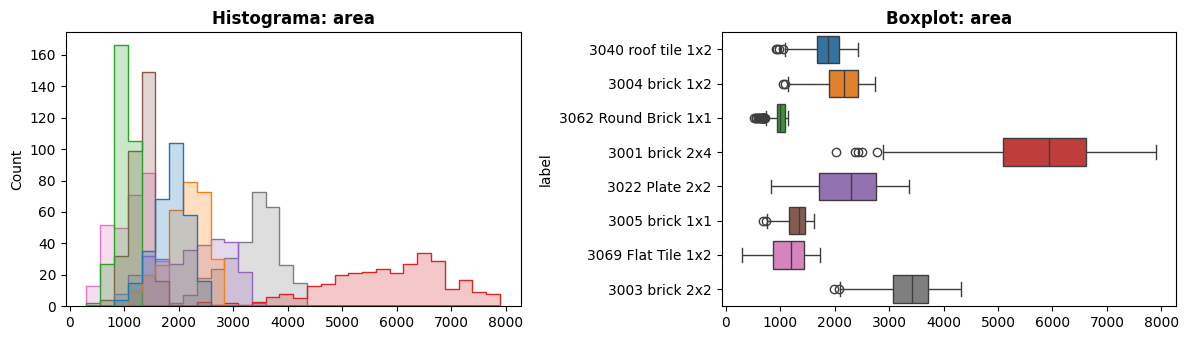

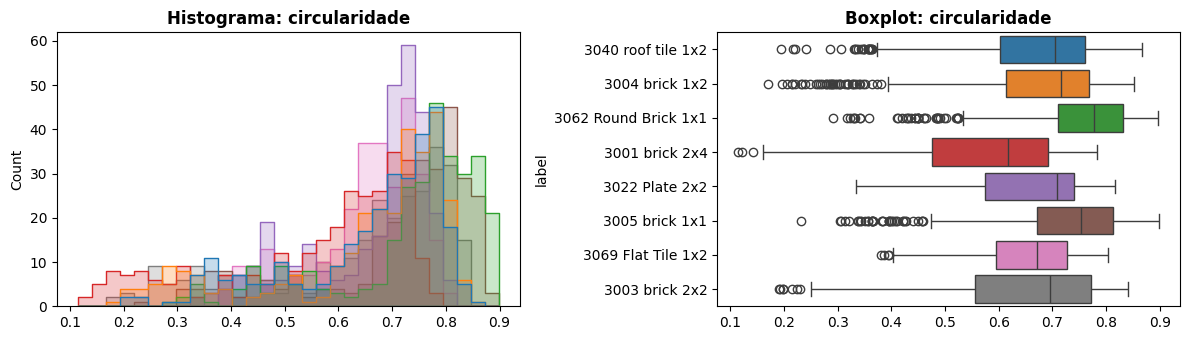

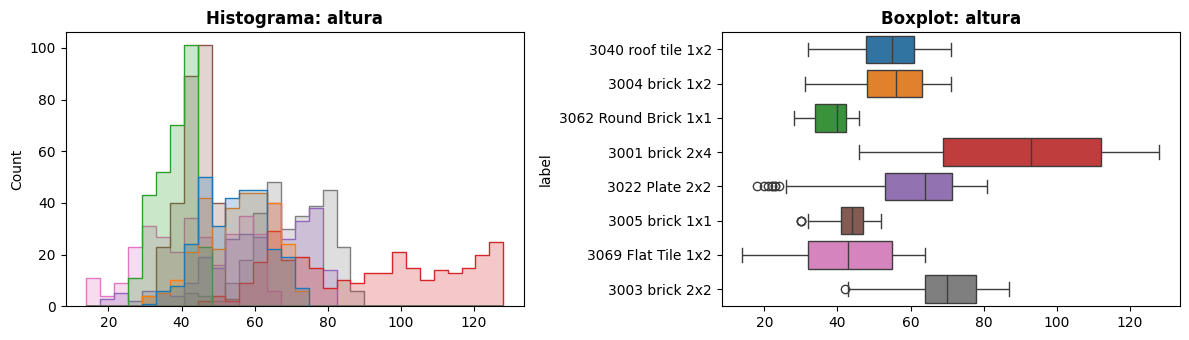

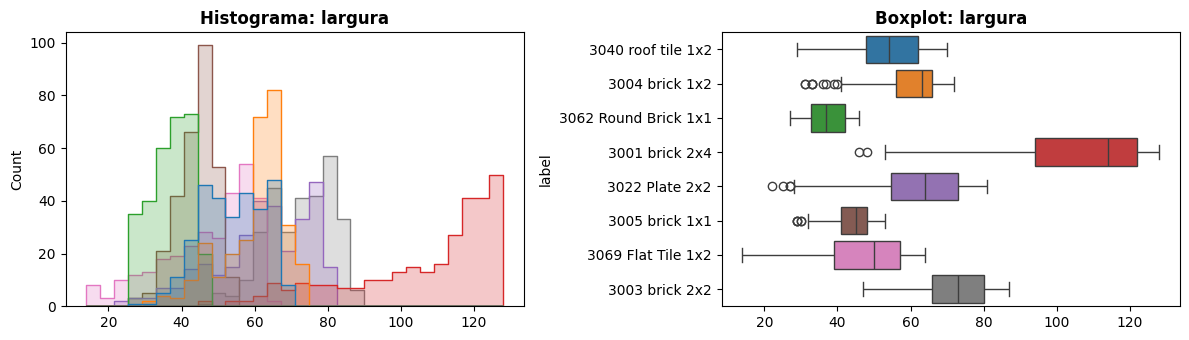

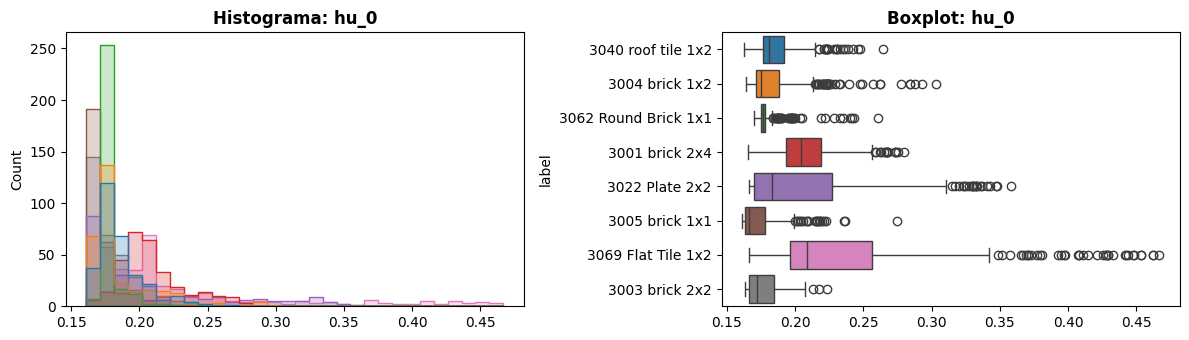

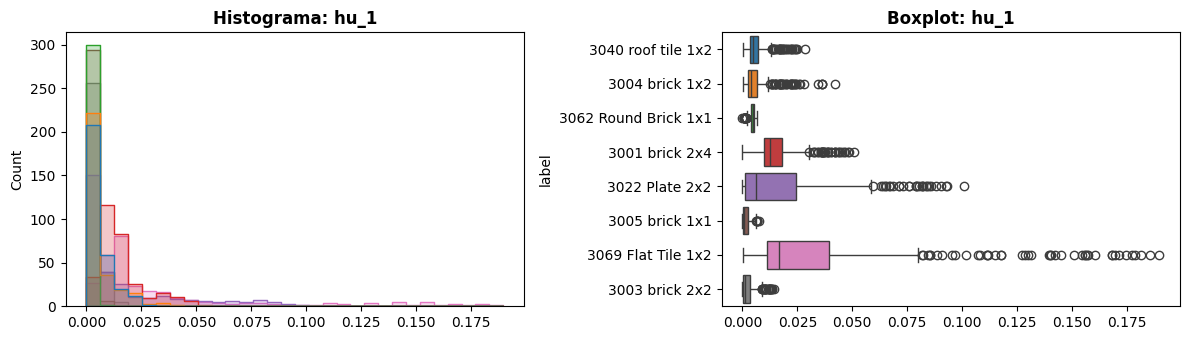

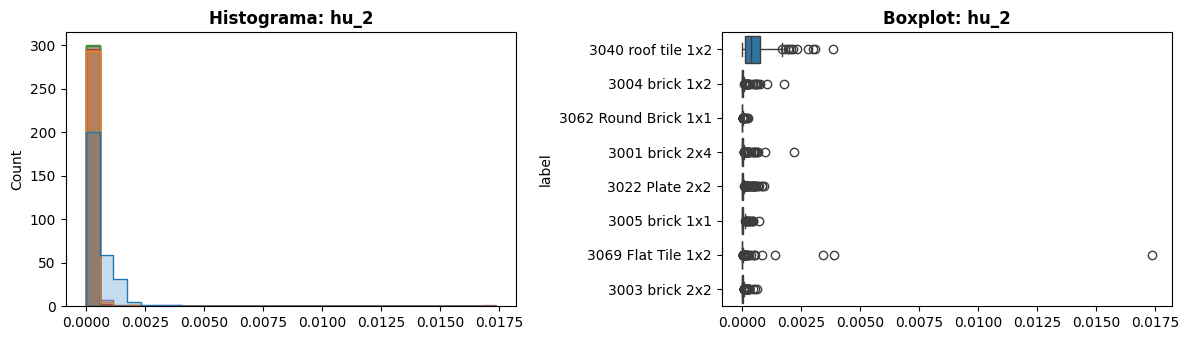

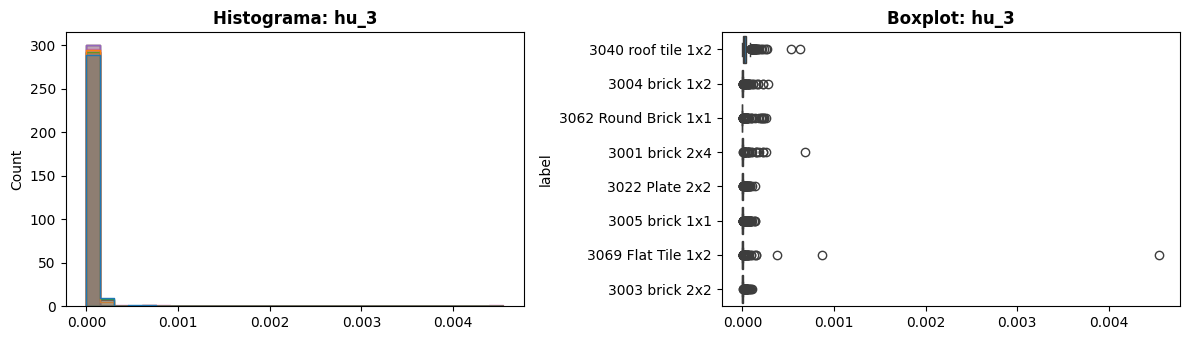

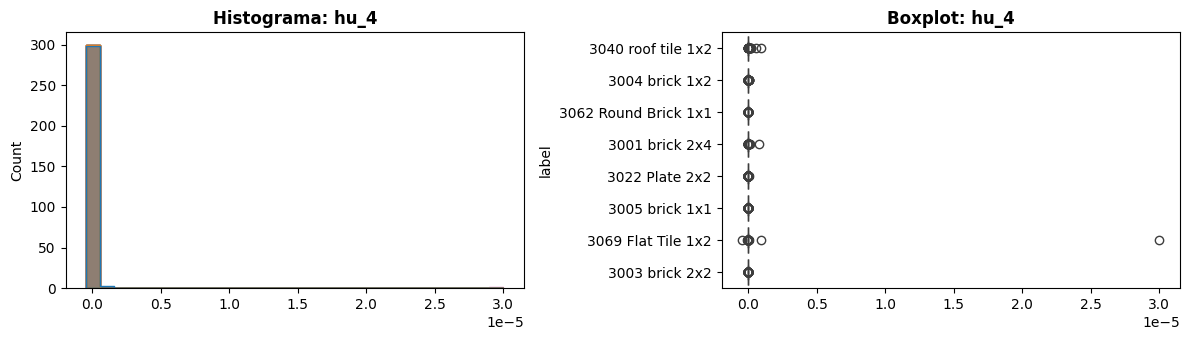

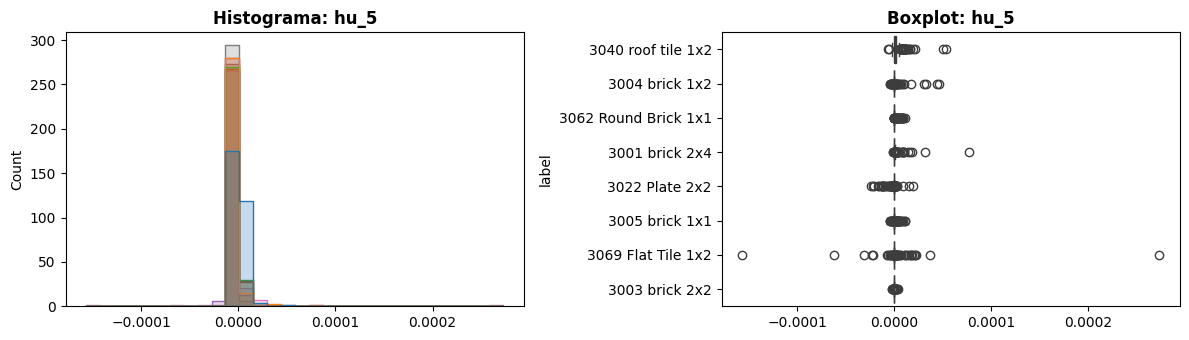

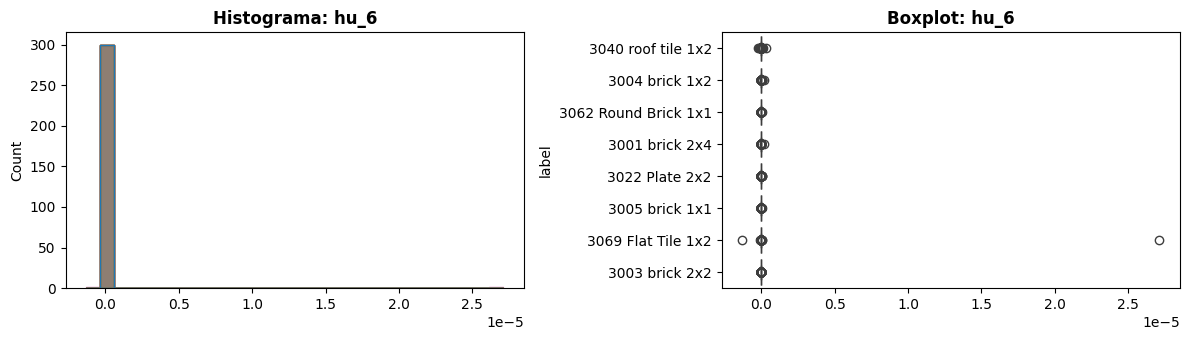

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

caracteristicas = [
    'area',
    'circularidade',
    'altura',
    'largura',
    'hu_0',
    'hu_1',
    'hu_2',
    'hu_3',
    'hu_4',
    'hu_5',
    'hu_6'
]
df_csv = pd.read_csv("features_separadas.csv")


for feat in caracteristicas:

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    # 1. Histograma (Esquerda)
    sns.histplot(
        data=df_csv,
        x=feat,
        hue='label',
        bins = 30,
        kde=False,  # Altere para True se o dataset for pequeno/médio
        element='step',
        common_norm=False,
        ax=axes[0]
    )
    axes[0].set_title(f'Histograma: {feat}', fontweight='bold')
    axes[0].set_xlabel('')

    # Remove legenda interna do histplot para economizar renderização
    if axes[0].get_legend():
        axes[0].get_legend().remove()

    # 2. Boxplot (Direita)
    sns.boxplot(
        data=df_csv,
        x=feat,
        y='label',
        hue='label',
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title(f'Boxplot: {feat}', fontweight='bold')
    axes[1].set_xlabel('')

    plt.tight_layout()
    plt.show()

    # CRÍTICO: Libera explicitamente a memória da figura atual do buffer do Matplotlib
    plt.close(fig)

In [26]:
caract_tabla = ['area', 'altura', 'largura', 'circularidade', 'hu_0', 'hu_1', 'hu_2', 'hu_3', 'hu_4', 'hu_5', 'hu_6' ]

tabela_limpa = (
    df_csv.groupby('label')[caract_tabla]
    .agg(['mean', 'std', 'median'])
    .round(2)
)

display(tabela_limpa)

area                  altura               largura  \
                         mean      std  median   mean    std median    mean   
label                                                                         
3001 brick 2x4        5808.47  1129.98  5932.0  91.42  23.05   93.0  106.24   
3003 brick 2x2        3355.96   491.41  3424.0  70.19   9.76   70.0   72.78   
3004 brick 1x2        2126.07   383.51  2179.0  55.28   9.42   56.0   60.05   
3005 brick 1x1        1306.29   195.38  1342.0  43.73   4.63   44.0   44.15   
3022 Plate 2x2        2237.63   641.31  2309.0  60.83  13.77   64.0   61.94   
3040 roof tile 1x2    1851.34   310.05  1887.0  54.41   8.86   55.0   54.03   
3062 Round Brick 1x1   986.88   125.47   998.0  38.37   4.95   40.0   36.90   
3069 Flat Tile 1x2    1151.37   346.74  1201.0  43.09  12.88   43.0   47.14   

                                   circularidade  ...   hu_3 hu_4              \
                        std median          mean  ... median mean  std median   
label                                             ...                           
3001 brick 2x4        20.14  114.0          0.56  ...    0.0  0.0  0.0    0.0   
3003 brick 2x2         8.70   73.0          0.64  ...    0.0  0.0  0.0   -0.0   
3004 brick 1x2         8.64   63.0          0.65  ...    0.0  0.0  0.0    0.0   
3005 brick 1x1         5.20   45.0          0.71  ...    0.0  0.0  0.0   -0.0   
3022 Plate 2x2        12.95   64.0          0.66  ...    0.0 -0.0  0.0   -0.0   
3040 roof tile 1x2     8.81   54.0          0.65  ...    0.0  0.0  0.0    0.0   
3062 Round Brick 1x1   5.35   37.0          0.73  ...    0.0 -0.0  0.0    0.0   
3069 Flat Tile 1x2    12.25   50.0          0.65  ...    0.0  0.0  0.0    0.0   

                     hu_5             hu_6              
                     mean  std median mean  std median  
label                                                   
3001 brick 2x4        0.0  0.0    0.0  0.0  0.0    0.0  
3003 brick 2x2       -0.0  0.0   -0.0 -0.0  0.0    0.0  
3004 brick 1x2        0.0  0.0    0.0  0.0  0.0   -0.0  
3005 brick 1x1        0.0  0.0    0.0 -0.0  0.0    0.0  
3022 Plate 2x2       -0.0  0.0   -0.0 -0.0  0.0   -0.0  
3040 roof tile 1x2    0.0  0.0    0.0 -0.0  0.0   -0.0  
3062 Round Brick 1x1  0.0  0.0    0.0  0.0  0.0    0.0  
3069 Flat Tile 1x2    0.0  0.0    0.0  0.0  0.0    0.0  

[8 rows x 33 columns]

In [113]:
#TEREI QUE FAZER UM LOGARITMO NOS VALORES DE HU E VOU TER QUE DEIXAR TODOS OS MEUS VALORES PADRONIZADOS PARA A MINHA ÁRVORE
#ALEM DISSO, ESTOU FAZENDO MINHA SEPARAÇÃO DE DADOS DE TESTE E DE TREINAMENTO

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_log = pd.read_csv('features_separadas.csv')
colunas_hu = ['hu_0', 'hu_1', 'hu_2', 'hu_3', 'hu_4', 'hu_5', 'hu_6']
def log_hu(valor):
    if valor == 0:
        return 0

    return -1 * np.log10(abs(valor)) if valor < 0 else np.log10(valor)
for coluna in colunas_hu:
    df_log[coluna] = df_log[coluna].apply(log_hu)

df_log.to_csv("features_com_log.csv", index=False)
df_standard = pd.read_csv("features_com_log.csv")
#------------------------------------------CRIAÇÃO DE TREINAMENTO E TESTE ---------------------------------------------------
X = df_standard.drop(columns=['filename',
                              'label',
                              #'solidity',
                              #'eccentricity',
                              #'aspect_ratio',
                              #'area',
                              #'altura',
                              #'largura',
                              #'circularidade',
                              #'hu_0',
                              #'hu_1',
                              #'hu_2',
                              #'hu_3',
                              'hu_4',
                              #'hu_5',
                              #'hu_6'
                              ])
y = df_standard['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#-----------------------------------------NORMALIZAÇÃO DOS DADOS-------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
#AGORA TENHO QUE TREINAR E TESTAR OS MODELOS
from sklearn.metrics import classification_report, accuracy_score
#------------------------------------------RANDOMFOREST----------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train_scaled, y_train)
y_pred = modelo.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print("Acurácia:", accuracy_score(y_test, y_pred))



                      precision    recall  f1-score   support

      3001 brick 2x4       1.00      0.92      0.96        60
      3003 brick 2x2       0.93      0.92      0.92        60
      3004 brick 1x2       0.84      0.85      0.84        60
      3005 brick 1x1       0.89      0.97      0.93        60
      3022 Plate 2x2       0.93      0.87      0.90        60
  3040 roof tile 1x2       0.93      0.92      0.92        60
3062 Round Brick 1x1       0.97      1.00      0.98        60
  3069 Flat Tile 1x2       0.90      0.95      0.93        60

            accuracy                           0.92       480
           macro avg       0.92      0.92      0.92       480
        weighted avg       0.92      0.92      0.92       480

Acurácia: 0.9229166666666667


In [114]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM (RBF)': SVC(random_state=42)
}

resultados = []

for name, model in models.items():

    if 'SVM' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    resultados.append({
        'Modelo': name,
        'Acurácia Teste': round(acc, 4)
    })

    print(f"=== {name} ===")
    print(f"Acurácia: {acc:.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

df_resultados = pd.DataFrame(resultados).sort_values(by='Acurácia Teste', ascending=False).reset_index(drop=True)
print("\n--- Comparativo de Acurácia ---")
print(df_resultados)

=== Decision Tree ===
Acurácia: 0.8479

Relatório de Classificação:
                      precision    recall  f1-score   support

      3001 brick 2x4       0.92      0.90      0.91        60
      3003 brick 2x2       0.86      0.83      0.85        60
      3004 brick 1x2       0.71      0.68      0.69        60
      3005 brick 1x1       0.90      0.78      0.84        60
      3022 Plate 2x2       0.84      0.87      0.85        60
  3040 roof tile 1x2       0.79      0.87      0.83        60
3062 Round Brick 1x1       0.95      0.93      0.94        60
  3069 Flat Tile 1x2       0.83      0.92      0.87        60

            accuracy                           0.85       480
           macro avg       0.85      0.85      0.85       480
        weighted avg       0.85      0.85      0.85       480

--------------------------------------------------
=== Random Forest ===
Acurácia: 0.9250

Relatório de Classificação:
                      precision    recall  f1-score   support

   

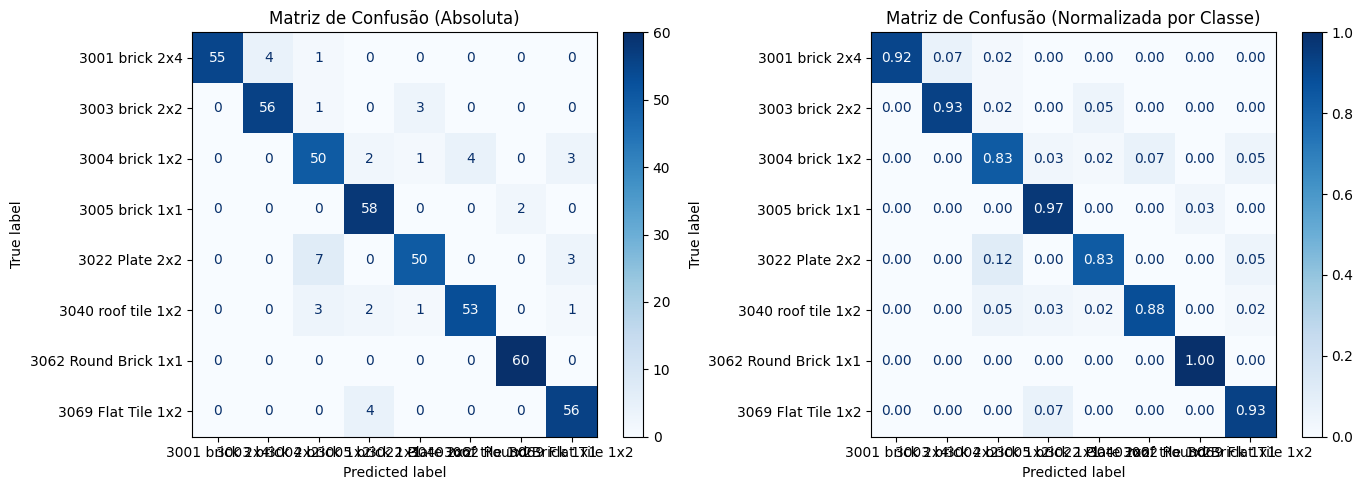

Acurácia anterior (apenas Hu / sem geométricas): 0.9125
Nova Acurácia (todas as características):       0.9125



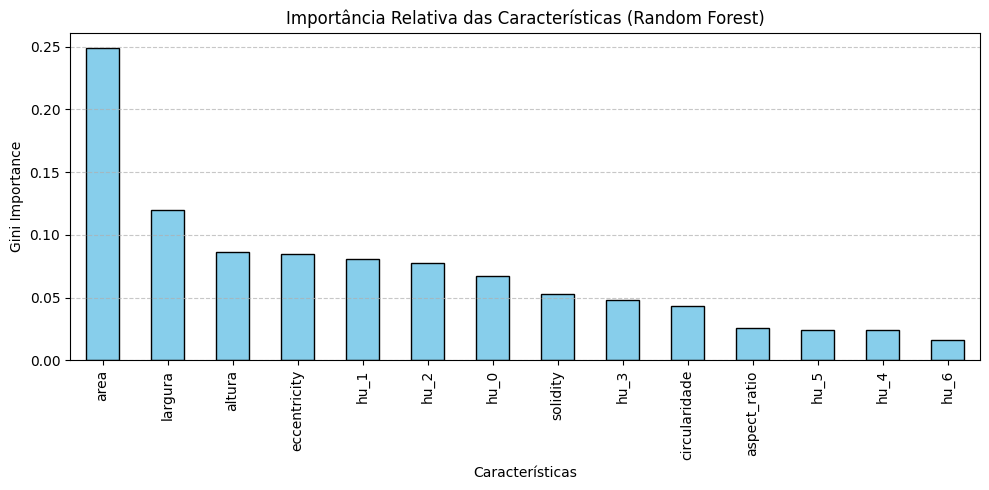

--- Ranking de Importância das Variáveis ---
area             0.248562
largura          0.119850
altura           0.086158
eccentricity     0.084796
hu_1             0.081078
hu_2             0.077273
hu_0             0.066896
solidity         0.053058
hu_3             0.048434
circularidade    0.043524
aspect_ratio     0.025506
hu_5             0.024573
hu_4             0.024387
hu_6             0.015904
dtype: float64


=== RANDOM FOREST (OTIMIZADO) ===
Melhores Hiperparâmetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Acurácia Média na Validação Cruzada: 0.9130
Acurácia Final no Conjunto de Teste: 0.9125

=== SVM (OTIMIZADO) ===
Melhores Hiperparâmetros: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Acurácia Média na Validação Cruzada: 0.9031
Acurácia Final no Conjunto de Teste: 0.9021


## Track B — Clasificación a partir de datos tabulares

Se te entrega la **ficha técnica** de cada pieza en `piezas_dataset.csv` (una fila por imagen del
dataset anterior; comparten la columna `filename`). La siguiente celda la carga y muestra las primeras
filas.

> **Ojo con el orden de las filas:** `df` (imágenes) y `df_tab` (ficha técnica) **no** tienen por
> qué quedar alineados fila a fila. Cruza siempre por `filename`, nunca por posición.


In [ ]:
# === Datos tabulares: carga del dataset entregado ===
df_tab = pd.read_csv('piezas_dataset.csv')
print('Dimensiones:', df_tab.shape)
df_tab.head(10)

### Tu desarrollo — Track B

Implementa aquí: análisis/descripción del dataset (con gráficos y/o tablas), limpieza (justificada),
selección de características (evitando *data leakage*) y el entrenamiento y comparación de los 4 modelos.

## Track C — Combinación de ambos mundos

Combina las mejores características de imágenes (Parte 1) y tabulares (Parte 2). Ambos conjuntos comparten
la columna `filename`, úsala para alinearlos. Desarrolla todo tu análisis según el enunciado.

### Tu desarrollo — Track C